# Steps for the exam
#### 1. Analyze the data and design appropriate transformations/preprocessing.  

#### 2. Train a model (training must happen on-the-fly when main.py is executed; it is possible, anyway, to run a grid search for parameter tuning and then use in the main.py file the desired model configuration).

#### 3. Predict labels for the provided test set.

#### 4. Save predictions to submission.csv (the file to be graded).

----

# Common steps for each model

#### 1. data inspection  
- import dataset as dataframe
- display the whole dataframe to have an idea and to have a generic look
- inspect shape (n rows and n column)
- inspect data type of each column --> see if you have labels  
###### (in general in the traccia of the exam it is written what kind of problem it is so you know if you have labels or not, usually you do)  

- check if columns are dirty or not --> like if there's dirty text --> clean by stripping / lower / replace --> so you spot hidden empty / fake not nan rows --> **replace with Nan**
- check if columns have nan-like values / values equivalent to (es. 0000-00-00 in timestamp) --> **replace with Nan**
- drop clear useless columns: almost-constant col + ID columns
- now that the data should be clean and actual data --> **MANAGE NAN** --> this changes for each model, figure it out:
    - analyse columns:
        - inspect the % of Nan in each column
        - understand how important is that column
            - if it's crucial --> KNNImpute if numerical / simplimpute if numerical or categorical / replace nan with '' if plaintext and needs TF-IDF
            - if it's less crucial think if to drop it / impute / replace with mean or 0
    
    - analyse rows:
        - say that a row is filled with Nans --> you drop it of course because it's garbage for the training
        - say that a crucial column has like 20 nan values --> you drop those rows
        - **BUT**: THE ROW FILTERING/DROPPING SHOULD BE DONE **ONLY** IN TRAINING, IN THE EVALUATION WHEN YOU CLEAN YOU CAN'T DROP ROWS OTHERWISE THE PREDICTED LABELS / TARGET VALUES WON'T MATCH THE SOLUTIONS --> KEEP ALL ROWS IN THE EVALUATION.
        - while if you drop whole columns in the training --> you can do for the evaluation too

- now data is cleaned and we handled Nan values accordingly
- plot data frequency + display column count values --> spot almost constant columns + columns with just one value + columns with outsider / anomalies + spot nan-like values (es. 0000-00-00 timestamp)

- based on the data type of each column --> think of the preprocess pipeline each (useful) column (if necessary):
    - SimpleImputer --> numbers and categories, but dumber / more naive
    - KNNImputer --> only numbers
    - OneHotEncode / TargetEncode --> categorical data + target encoder especially if you have many unique values
    - OrdinalEncode --> ordinal columns + timestamps
    - Tokenizer + lemmatize + TF-IDF + CSV --> plaintext cols
    - StandardScaler --> numeric data that needs to be scaled
    - MinMaxScaler --> 
    - PolynomialFeatures --> ONLY COLUMNS WITH HIGHEST CORRELATION WITH THE TARGET, otherwise the dimension explodes

- feed the preprocessed data to the model
- train + tune it
- predict
- evaluate

- in the exam you have an evaluation set, but without labels --> keep a small piece (10/20 %) of the train data an use it as evaluation, don't train on that piece --> useful to see the model actual score.
- At the end don't forget to add that data you left as evaluation to the training though.

---

# Classification
- after preprocessing data with a preprocessing pipeline, build a classification model pipeline:
    - build the classifier model:
        - decision tree
        - **random forest**
        - bayesian classifier
        - **KNN classifier**
        - **support vector machines --> SVC, linear SVC**
    - tune the hyperparameters --> GridSearchCV
    - find the best model (automatically trained by the gridsearch)
    - import, clean (WITHOUT DROPPING ROWS), preprocess (WITHOUT RE-BUILDING THE TOOLS BUT RE-USING THE ONES CREATED IN THE TRAINING) evaluation set
    - use the already trained best model to predict the cleaned + preprocessed evaluation set
    - move the predictions to a csv

In [63]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.compose import ColumnTransformer

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
dataset = load_breast_cancer ()
x = dataset["data"]
y = dataset["target"]
feature_names = dataset ["feature_names"]

print(x.shape)
print(y.shape)

df_complete = pd.DataFrame(x, columns=feature_names)
df_complete['target'] = y

display(df_complete)

(569, 30)
(569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [7]:
df = df_complete.copy()
labels = df['target']
df.drop(columns='target', inplace=True)

In [8]:
# for col in df:
#     if df[col].isnull().sum():
#         print(col, df[col].isnull().sum())

mask = df.isna().sum(axis=0) > 0
print(df.loc[:, mask])

# No explici Nans --> other possible Nans == negative values or 0

Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]

[569 rows x 0 columns]


In [9]:
mask_col = (df<=0).any(axis=0)
mask_row = (df<=0).any(axis=1)
display(df.loc[mask_row, mask_col])

print('columns with values <= 0:')
for col in df:
    nan_like_count = (df[col] <= 0).sum()
    if nan_like_count:
        print(col, nan_like_count)


,mean concavity,mean concave points,concavity error,concave points error,worst concavity,worst concave points
101,0.0,0.0,0.0,0.0,0.0,0.0
140,0.0,0.0,0.0,0.0,0.0,0.0
174,0.0,0.0,0.0,0.0,0.0,0.0
175,0.0,0.0,0.0,0.0,0.0,0.0
192,0.0,0.0,0.0,0.0,0.0,0.0
314,0.0,0.0,0.0,0.0,0.0,0.0
391,0.0,0.0,0.0,0.0,0.0,0.0
473,0.0,0.0,0.0,0.0,0.0,0.0
538,0.0,0.0,0.0,0.0,0.0,0.0
550,0.0,0.0,0.0,0.0,0.0,0.0


columns with values <= 0:
mean concavity 13
mean concave points 13
concavity error 13
concave points error 13
worst concavity 13
worst concave points 13


- of course 0 is not a measure, they're actually Nans --> replace with Nans and later on when we manage nans we could replace them with median / mean
- **BUT** since this is a pre-made sklearn dataset I believe there might be a reason those values are there ... I'll ignore them for now

In [10]:
# check rows
mask = df.isnull().sum(axis=1) > 0
# display(df.loc[mask, :])

mask = (df <= 0).any(axis=1)
# display(df.loc[mask, :])

print('rows with values <= 0:')
for row in df.index:
    nan_like_count = (df.loc[row, :] <= 0).sum()
    if nan_like_count:
        print(f"row {row}", nan_like_count)


rows with values <= 0:
row 101 6
row 140 6
row 174 6
row 175 6
row 192 6
row 314 6
row 391 6
row 473 6
row 538 6
row 550 6
row 557 6
row 561 6
row 568 6


- the actual pipeline would have been to replace all these 0 values with Nans, but this is a sklean dataset, it's already cleaned so I trust them and there's a reason why those 0 values are there
- but I was supposed to replace with Nan and then decide what to do

---

In [11]:
df.columns
# no clearly useless columns (like ID) --> no drop

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')

In [12]:
df.shape

(569, 30)

In [13]:
info = df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

- all numbers
- no categroical
- no ordinal

In [14]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


- all the columns needs to be scaled --> NOT if we use an ensemble method like random forest

In [15]:
df.shape

(569, 30)

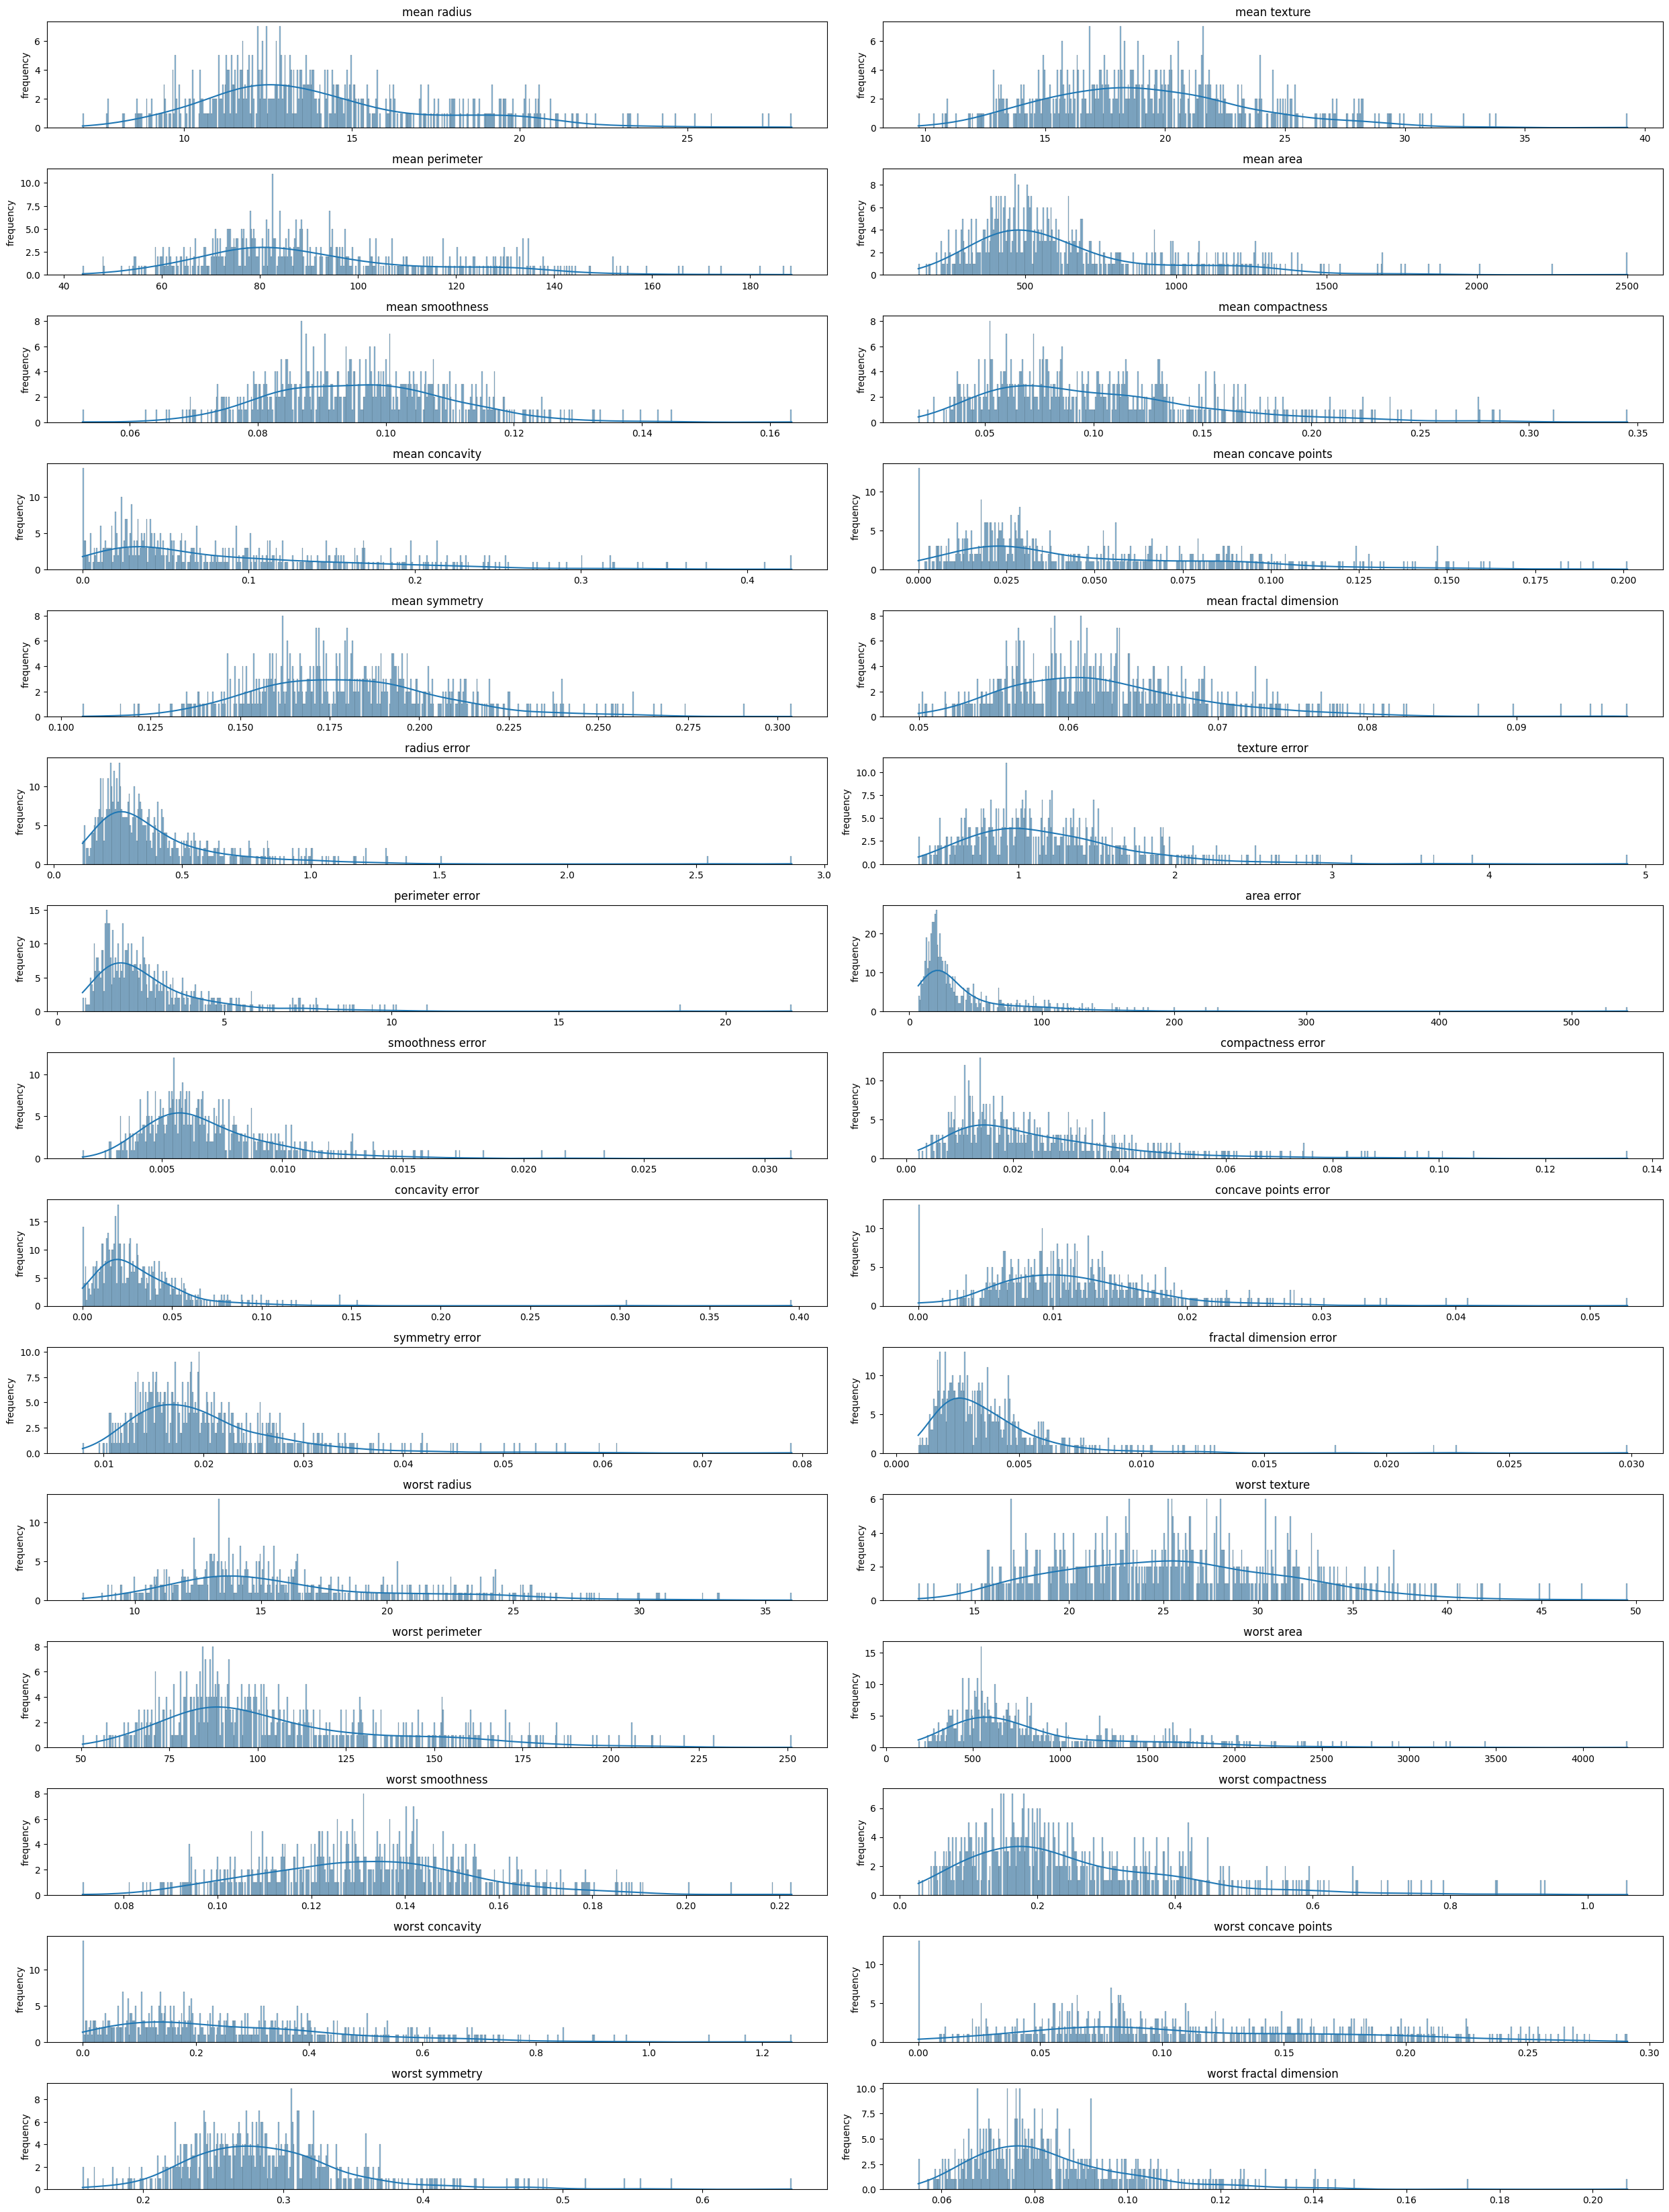

In [16]:
# visualize data
plt.figure(figsize=(25,35))
for plt_idx, col in enumerate(df):
    n_bins = len(df[col].values)
    x = df[col].values

    plt.subplot(16,2, plt_idx+1)
    sns.histplot(x=x, bins=n_bins, kde=True)
    
    # sns.histplot(x=x, bins='auto', kde=True)
    # plt.hist(x=x, bins=n_bins)
    # sns.countplot() --> nope, use it for categorical
    
    plt.ylabel('frequency')
    plt.title(f"{col}")

plt.tight_layout()
plt.show()



- those 0 spikes are very very weird .... I'm trusting sklearn but they might actually be anomalies!

---

Idea of the workflow:
- model 1:
    - split data into train and evaluation
    - try directly feeding the df to a random classifier (without even scaling, random forest doesn't like the scaler)
    - use a gridsearch
    - train + predict on the evaluation + evaluate

In [ ]:
df = df_complete

# split data
labels = df['target'].values
data = df.iloc[:,:30].values
x_train, x_ev, y_train, y_ev = train_test_split(data, labels, random_state=42, shuffle=True, train_size=0.8, test_size=0.2)

# set param grid for the gridsearch
param_grid = {
    'n_estimators':[100,200],
    'min_samples_leaf':[1, 5, 10],
    'min_samples_split':[2, 5],
    'max_depth': [None, 10]
}

# build the classifier used by the gird
rf = RandomForestClassifier(bootstrap=True, n_jobs=-1, random_state=42)

# build grid and perform gridsearch
grid = GridSearchCV(estimator=rf, param_grid=param_grid, n_jobs=-1, cv=3, verbose=2)

# fit the grid + take best model (DO NOT RETRAIN IT, ALREADY TRAINED) + predict using the best model + evaluate
grid.fit(x_train, y_train)
best_model = grid.best_estimator_
print(grid.best_params_)

y_pred = best_model.predict(x_ev)
print(classification_report(y_ev, y_pred))

# move predictions to CSV file
pred_df = pd.DataFrame({'ID': range(len(y_pred)), 'predictions' : y_pred})
pred_df.to_csv('predictions_model1.csv', index=False)

# REMEMBER TO RETRAIN THE MODEL ON EVERYTHING, evaluation set too!!!
# so do:
best_model.fit(data, labels)

# and now you can process the evaluation set with the newly trained model, I simpli added more training info :)



---

- model 2
    - split data into training (80%) and evaluation data (20%)
    - pipeline:
        - replace those 0 values with Nans + SimpleImputer / KNNImputer
        - StandardScaler (avoid if you use a tree classifier)
        - classification model pipeline
    - build parameters grid + feed pipeline to a grid  --> grid search
    - get best model
    - **transform evaluation data passing it into the pipeline AS TRANSFORM, NOT FIT TRANSFORM**
    - predict the transformed evaluation data

Note:    
- plot to figure out K: plot n_neighbours on X and F1 score on Y and look for an elbow
- use a KNN
- use SVM

In [ ]:
# split data
data = df.loc[:, 'mean radius':'worst fractal dimension'].values
labels = df['target'].values
x_train, x_ev, y_train, y_ev = train_test_split(data, labels, train_size=0.8, test_size=0.2, random_state=42, shuffle=True)

# pipeline:
    # preprocessing: imputer + scaler
    # model: KNN

prep_and_model_pipeline = Pipeline(steps=[
    (
        'SimpleImputer',
        SimpleImputer()
    )
    ,
    (
        'scaler',
        StandardScaler()
    )
    ,
    (
        'KNN',
        KNeighborsClassifier(n_jobs=-1)
    )
])


param_grid = {
    'SimpleImputer__strategy': ['median', 'mean', 'most_frequent'],
    'KNN__n_neighbors' : [5, 10, 20]            # n_neighbors figure it out using cross validation --> performed during hyperparameters tuning through a gridsearch --> this is the practical way --> the theoretically correct way is through plot
}

grid = GridSearchCV(estimator=prep_and_model_pipeline, param_grid=param_grid, n_jobs=-1, cv = 4, verbose=2)
grid.fit(x_train, y_train)
print(grid.best_params_)
best_model = grid.best_estimator_

# DUMBASS: DO NOT FORGET TO TRANSFORM EVALUATION BEFORE PREDICTING IT, YOU'RE NOT PREDICTING ON RAW EVALUATION
# FORTUNATELY THE PIPELINES ARE VERY SMART SO WHEN YOU .PREDICT IT ALREADY TRANSFORMS THE DATA --> best_model.predict(x_ev) transforms x_ev passing it through imputer + scaler THEN predicts after transforming

y_pred = best_model.predict(x_ev)
print(classification_report(y_ev, y_pred))
print(confusion_matrix(y_ev, y_pred))

# REMEMBER TO RETRAIN THE MODEL ON EVERYTHING, evaluation set too!!!


- same model but I'll use a SVM

In [ ]:
# split data
data = df.loc[:, 'mean radius':'worst fractal dimension'].values
labels = df['target'].values
x_train, x_ev, y_train, y_ev = train_test_split(data, labels, train_size=0.8, test_size=0.2, random_state=42, shuffle=True)

# pipeline:
    # preprocessing: imputer + scaler
    # model: linearSVC

prep_and_model_pipeline = Pipeline(steps=[
    (
        'SimpleImputer',
        SimpleImputer()
    )
    ,
    (
        'scaler',
        StandardScaler()
    )
    ,
    (
        'SVC',
        LinearSVC(random_state=42)
    )
])


param_grid = {
    'SimpleImputer__strategy': ['median', 'mean', 'most_frequent'],
    "SVC__penalty": ["l2"],
    "SVC__loss": ["squared_hinge"],
    "SVC__C": [1e-3, 1, 10, 100],
    "SVC__class_weight": [None, "balanced"],
}

grid = GridSearchCV(estimator=prep_and_model_pipeline, param_grid=param_grid, n_jobs=-1, cv = 4, verbose=2)
grid.fit(x_train, y_train)
print(grid.best_params_)
best_model = grid.best_estimator_

# DO NOT FORGET TO TRANSFORM EVALUATION BEFORE PREDICTING IT, YOU'RE NOT PREDICTING ON RAW EVALUATION --> the pipeline has in it preprocessing + model, so the predict on the pipeline already handles it luckly
y_pred = best_model.predict(x_ev)
print(classification_report(y_ev, y_pred))
print(confusion_matrix(y_ev, y_pred))

# REMEMBER TO RETRAIN THE MODEL ON EVERYTHING, evaluation set too!!!

- the one In just did is the practical way to figure out the number of neighbours, which is apparently 10
- the theoretically correct way to figure out the number of neighbours:
    - plot n_neighbours on X
    - respective achieved F1 score (or other metrics) on Y
    - look for an elbow

- if it doesn't work --> cross validation through a girdsearch

[2, 5, 10, 20]
[0.950354609929078, 0.9577464788732394, 0.9645390070921985, 0.965034965034965]


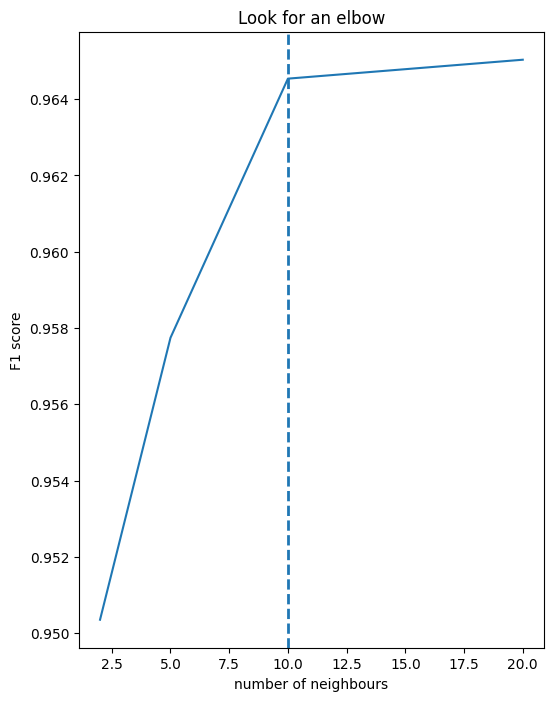

In [61]:
# split data
data = df.loc[:, 'mean radius':'worst fractal dimension'].values
labels = df['target'].values
x_train, x_ev, y_train, y_ev = train_test_split(data, labels, train_size=0.8, test_size=0.2, random_state=42, shuffle=True)

# pipeline:
    # preprocessing: imputer + scaler
    # model: KNN

preprocessing_pipeline = Pipeline(steps=[
    (
        'SimpleImputer',
        SimpleImputer(strategy='median')
    )
    ,
    (
        'scaler',
        StandardScaler()
    )
])

x_train_prep = preprocessing_pipeline.fit_transform(x_train)

f1_scores = []
neighbours = [2,5,10,20]
for n in neighbours:
    knn = KNeighborsClassifier(n_neighbors=n, n_jobs=-1)
    knn.fit(x_train_prep, y_train)
    
    # DO NOT FORGET TO TRANSFORM EVALUATION BEFORE PREDICTING IT, YOU'RE NOT PREDICTING ON RAW EVALUATION
    x_ev_preprocessed = preprocessing_pipeline.transform(x_ev)
    y_pred = knn.predict(x_ev_preprocessed)
    score = f1_score(y_ev, y_pred)
    f1_scores.append(score)


print(neighbours)
print(f1_scores)

plt.figure(figsize=(6,8))
plt.plot(neighbours, f1_scores)
plt.axvline(x=10, linestyle="--", linewidth=2)      # vertical line
# plt.axhline horizontal line
plt.xlabel('number of neighbours')
plt.ylabel('F1 score')
plt.title('Look for an elbow')
plt.show()


---

- model 3:
- Let's ay that after trying a linear model (linear SVC) you see that it underfits (not our case but pretend) --> you need something more complex --> then you go for polynomial features:
    - how do I figure out on which columns / rows should I compute polynomial features?
1.	Compute C1 = |corr(x, y)|  
2.	Create x^2 features (PolynomialFeatures degree =2, squares only), compute C2.  
3.	Flag candidates where correlation in C2 is high and correlation in C2 ≫ correlation in C1 (or C1 is small but C2 is large). To be sure about it cross validate it and compare to a linear model:
- Build a pipeline MODEL A with like imputer + scaling + linear classifier --> get scoring  
- AND COMPARE IT WITH MODEL B imputer + scaler + PolynomialFeatures on the previously selected columns + same previous linear model


    - split into training (80%) and evaluation data (20%)
    - preprocessing:
        - replace those 0 values with Nans + SimpleImputer / KNNImputer
        - StandardScaler (avoid if you use a tree classifier)
        - PolynomialFeatures on the most correlated rows
    - use KNN or SVD

In [ ]:
row_mask_0 = df.loc[:,'target'] == 0
row_mask_1 = df.loc[:,'target'] == 1
# x_1 = df.loc[row_mask_1, ['mean texture','target']]
# display(x_1)

plt.figure(figsize=(20,20))
for plt_idx, col in enumerate(df):
    x_0 = df.loc[row_mask_0, col]
    x_1 = df.loc[row_mask_1, col]
    
    plt.subplot(11,3,plt_idx+1)
    # bins=len(x_0)
    sns.histplot(x=x_0, bins='auto', color='blue')
    sns.histplot(x=x_1, bins='auto', color='red')
    plt.title(f'frequency {col}')
plt.tight_layout()
plt.show()


In [ ]:
data = df.loc[:, 'mean radius':'worst fractal dimension']

# correlation 
corr_1 = data.corrwith(df['target']).abs().sort_values(ascending=False)

# polynomial degree 2
PF = PolynomialFeatures(degree=2)
data_2 = PF.fit_transform(data)

# convert back to dataframe
columns = PF.get_feature_names_out()
data_2 = pd.DataFrame(data_2, columns=columns)

# again correlation + spot high and higher values
corr_2 = data_2.corrwith(df['target']).abs().sort_values(ascending=False)

print("Top 5 correlation between each col and target:")
print(corr_1)
print()
print("Top 5 correlation between each squared col and target:")
print(corr_2)

- results:  
worst perimeter worst smoothness            0.807730 --> worst perimeter            0.782914 ; worst smoothness           0.421465  
worst radius worst smoothness               0.806675 --> worst radius               0.776454 ; worst smoothness           0.421465  
worst texture worst concave points          0.806100 --> worst texture              0.456903 ; worst concave points       0.793566  
mean texture worst concave points           0.803809 --> mean texture               0.415185 ; worst concave points       0.793566  
worst radius worst concave points           0.800448 --> worst radius               0.776454 ; worst concave points       0.793566  

- any good candidates?
- does the interaction add meaningful signal beyond the strongest base feature?

For each pair, compare corr_2 vs max(corr_1_base_1, corr_1_base_2):
- worst perimeter * worst smoothness: 0.8077 vs max(0.7829, 0.4215)=0.7829 → +0.0248
- worst radius * worst smoothness: 0.8067 vs max(0.7765, 0.4215)=0.7765 → +0.0302
- worst texture * worst concave points: 0.8061 vs max(0.4569, 0.7936)=0.7936 → +0.0125
- mean texture * worst concave points: 0.8038 vs max(0.4152, 0.7936)=0.7936 → +0.0102
- worst radius * worst concave points: 0.8004 vs max(0.7765, 0.7936)=0.7936 → +0.0069

Those gains are small (0.007–0.030). The interaction is not adding info because the linear features are already strong.  
**BUT**, out of practice I'll still perform polynomial features on **worst radius × worst smoothness**.

In [62]:
# build the baseline model, you'll compare the one that has polynomial features to these scores

data = df.loc[:, 'mean radius':'worst fractal dimension']
labels = df['target']
x_train, x_ev, y_train, y_ev = train_test_split(data, labels, train_size=0.8, test_size=0.2, random_state=42, shuffle=True)

classification_pipeline = Pipeline(steps=[
    (
        'imputer',
        KNNImputer()
    )
    ,
    (
        'scaler',
        StandardScaler()
    )
    ,
    (
        'classifier',
        LinearSVC(random_state=42)
    )
])

param_grid = {
    'imputer__n_neighbors' : [3,5,8,10,15],
    'classifier__C' : [0.001, 0.1, 1, 10, 100]
}

grid = GridSearchCV(estimator=classification_pipeline, param_grid=param_grid, n_jobs=-1, cv=3)
grid.fit(x_train, y_train)
print(grid.best_params_)

best_model = grid.best_estimator_
y_pred = best_model.predict(x_ev)
print(classification_report(y_ev, y_pred))




{'classifier__C': 0.1, 'imputer__n_neighbors': 3}
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [ ]:
# try polynomial features on worst radius × worst smoothness --> select worst radius and worst smoothness
    # 2 preprocessing pipelines:
    # pipeline 1: base pipeline --> imputer + scaler
    # pipeline 2: poly pipeline --> imputer + scaler + polynomial features
    # tie the 2 preprocessing pipeline in one preprocessing pipeline with columntransformer

    # model pipeline: preprocessing pipeline (which are the 2 pipelines tied) + model

data = df.loc[:, 'mean radius':'worst fractal dimension']
labels = df['target']
x_train, x_ev, y_train, y_ev = train_test_split(data, labels, train_size=0.8, test_size=0.2, random_state=42, shuffle=True, stra)

# pick the column names for the column transformer
poly_col = ['worst radius', 'worst smoothness']
base_col = ['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst texture', 'worst perimeter', 'worst area',
       'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension']

base_pipeline = Pipeline(steps=[
    (
        'imputer',
        KNNImputer()
    )
    ,
    (
        'scaler',
        StandardScaler()
    )
])

poly_pipeline = Pipeline(steps=[
    (
        'imputer',
        KNNImputer()
    )
    ,
    (
        'scaler',
        StandardScaler()
    )
    ,
    (
        'poly',
        PolynomialFeatures(include_bias=False, interaction_only=True)
    )
])

# tie them up
preprocessing_pipeline = ColumnTransformer(transformers=[
    ('base_pipe', base_pipeline, base_col)
    ,
    ('poly_pipe', poly_pipeline, poly_col)]
    ,
    n_jobs=-1)


# model pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessing_pipeline)
    ,
    ('model', LinearSVC(C=0.1, random_state=42))
])

param_grid={
    'preprocessing__base_pipe__imputer__n_neighbors': [3,5,10],         # it would make sense to use just one KNN imputer, but whatever :)
    'preprocessing__poly_pipe__imputer__n_neighbors' : [3,5,10],
    'preprocessing__poly_pipe__poly__degree': [2],                      # [1,2] to see what it prefers ... spoiler it prefers 1
    'model__C':[0.001, 0.1, 1, 10]
}

grid = GridSearchCV(estimator=full_pipeline, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid.fit(x_train, y_train)
print(grid.best_params_)
best_model = grid.best_estimator_

# the grid uses the full pipeline which also manages preprocessing, so no need for explicitly preprocessing
y_pred = best_model.predict(x_ev)
print(classification_report(y_ev, y_pred))


# get score and compare to score of same model without polynomialfeatures step to see if it improves it or not
# there's no difference in the score of the 2 models --> this change is absolutely useless ... we knew that since the beginning but I need to practice :)

